In [1]:
import sys
sys.path.append("../")

In [2]:
INTERVAL_LOW = 0
INTERVAL_HIGH = 100
SAMPLES = int(1e5)

def system(y, t):
    S, I, R = y
    dSdt = -0.2 * S * I / 1000
    dIdt = 0.2 * S * I / 1000 - 0.1 * I
    dRdt = 0.1 * I
    return dSdt, dIdt, dRdt

def get_time_norm_function(function, max_time):
    def function_norm_time(t):
        return function(t * max_time)

    return function_norm_time



class ExactModel:
    def eval_model(self, X):
        return [-0.2 * (X[1] * 1000) * X[2] * 1000 / 1000]


exact = ExactModel()

In [4]:
from interpolation.regression_dataset import RegressionDataset
from interpolation.interpolate_system import odeint_interpolate

y_inter = odeint_interpolate( system, [1000, 1, 0], INTERVAL_LOW, INTERVAL_HIGH, 10000 )
y_inter_time_norm = [get_time_norm_function(yi, INTERVAL_HIGH) for yi in y_inter]

def y_prime1(t):
    return float(-0.2 * y_inter_time_norm[0](t) * y_inter_time_norm[1](t) / 1000)

print("Generating training data...")
dataset_train = RegressionDataset(y_inter_time_norm, y_prime1, 0,1, SAMPLES * 80 // 100)
dataset_test = RegressionDataset(y_inter_time_norm, y_prime1, 0,1, SAMPLES * 20 // 100)
print("Done")

Generating training data...
Done


In [5]:
%load_ext autoreload
%autoreload 2
from interpolation.regression_nn import RegressionNN

m1 = RegressionNN.nn_regression(0, 1, y_inter_time_norm, y_prime1, int(1e5), 2048, 20, dataset_train, dataset_test )

epoch: 0
Avg loss: 16.676984596252442
epoch: 1
Avg loss: 0.0719571866095066
epoch: 2
Avg loss: 0.0015015533776022495
epoch: 3
Avg loss: 0.0010938263381831347
epoch: 4
Avg loss: 0.00038724251789972185
epoch: 5
Avg loss: 0.10428395271301269
epoch: 6
Avg loss: 0.005687317764386535
epoch: 7
Avg loss: 0.0002310712297912687
epoch: 8
Avg loss: 0.00026740513276308776
epoch: 9
Avg loss: 0.026097200997173785
epoch: 10
Avg loss: 0.0010106384637765587
epoch: 11
Avg loss: 0.00035527810105122625
epoch: 12
Avg loss: 0.006144072487950325
epoch: 13
Avg loss: 0.006569908652454615
epoch: 14
Avg loss: 0.00036956265976186844
epoch: 15
Avg loss: 0.026019690185785295
epoch: 16
Avg loss: 0.0003660805057734251
epoch: 17
Avg loss: 0.00011155499232700095
epoch: 18
Avg loss: 0.10682639554142952
epoch: 19
Avg loss: 0.000599122152198106


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
selected t0: 0.8173428269429643
S(t0) = 334.1745159410688


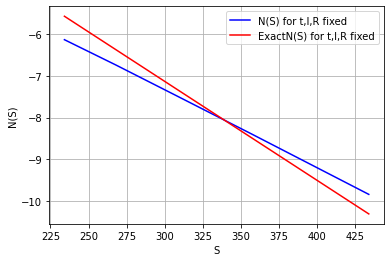

In [46]:
%load_ext autoreload
%autoreload 2
from query_set.graph_dependency import dependency_graph_epsilon
import matplotlib.pyplot as plt

dependency_graph_epsilon(
        m1,
        1,
        y_inter_time_norm,
        0,
        1,
        1000,
        "N(S) for t,I,R fixed",
        "b",
        exact
    )


plt.show()